# Gradient descnt and logistic regression

## 1. Gradient descent

For a two-coefficient system where $f(x, y) = 2(x^2 - x + y^2 + y)$, compute the gradient. Then show the gradient descend process, start with $x = y = 2$. Show that a learning rate of $\gamma = 0.25$ is an excellent choice, while $\gamma = 0.5$ will never make the algorithm converge.

In [2]:
import numpy as np

def compute_gradient(vec):
    """
    Computes the gradient based on the function provided.
    Given: ∇f = 2(x^2 - x + y^2 + y)
    We interpret this as:
    df/dx = 4x - 2
    df/dy = 4y + 2
    """
    x, y = vec[0], vec[1]
    grad_x = 4*x - 2
    grad_y = 4*y + 2
    return np.array([grad_x, grad_y])

def simulate_gradient_descent(eta, iterations=6):
    # Starting values x = 2, y = 2
    current_pos = np.array([2.0, 2.0])

    print(f"\n--- Testing Learning Rate (η): {eta} ---")
    print(f"Start: x={current_pos[0]}, y={current_pos[1]}")

    for i in range(iterations):
        grad = compute_gradient(current_pos)
        current_pos = current_pos - eta * grad

        # Check for divergence to stop early if values explode
        if np.any(np.abs(current_pos) > 1e6):
            print(f"Iteration {i+1}: Diverging! Values: {current_pos}")
            break

        print(f"Iteration {i+1}: x={current_pos[0]:.4f}, y={current_pos[1]:.4f}")

# 1. Show that η = 0.25 is an excellent choice (Converges)
simulate_gradient_descent(eta=0.25)

# 2. Show that η = 0.5 makes the algorithm diverge
simulate_gradient_descent(eta=0.5)


--- Testing Learning Rate (η): 0.25 ---
Start: x=2.0, y=2.0
Iteration 1: x=0.5000, y=-0.5000
Iteration 2: x=0.5000, y=-0.5000
Iteration 3: x=0.5000, y=-0.5000
Iteration 4: x=0.5000, y=-0.5000
Iteration 5: x=0.5000, y=-0.5000
Iteration 6: x=0.5000, y=-0.5000

--- Testing Learning Rate (η): 0.5 ---
Start: x=2.0, y=2.0
Iteration 1: x=-1.0000, y=-3.0000
Iteration 2: x=2.0000, y=2.0000
Iteration 3: x=-1.0000, y=-3.0000
Iteration 4: x=2.0000, y=2.0000
Iteration 5: x=-1.0000, y=-3.0000
Iteration 6: x=2.0000, y=2.0000


## 2. Logits and probability

In logistic regression, the "logit" $z$ is calculated as $z = wx + b$. This value is then passed through the sigmoid function to get a probability.

1. If the weight $w = 0.5$, the bias $b = -2$, and the input $x = 6$, calculate the logit $z$.
2. Use your sigmoid function to find the probability $p(X)$.
3. Does the model predict "Pass" (1) or "Fail" (0) based on the 0.5 boundary?
4. Try changing the input $x$ to see how it affects the logit, probability, and prediction. For example, what happens if $x = 3$, $x=4$ or $x = 8$?

In [8]:
def logit(w, x, b):
    z = w * x + b
    print(f"Logit (z): {z}")

def sigmoid(z):
    p_X =  1 / (1 + np.exp(-z))
    print(f"Probability p(X): {p_X}")
    return p_X

def predict(p_X):
    prediction = 1 if p_X >= 0.5 else 0
    print(f"Model Prediction: {'Pass (1)' if prediction == 1 else 'Fail (0)'}")

def run_logistic_regression(w, x, b):
    z = w * x + b
    p_X = sigmoid(z)
    predict(p_X)

In [9]:
w = 0.5
b = -2
x = 6

run_logistic_regression(w, x, b)

Probability p(X): 0.7310585786300049
Model Prediction: Pass (1)


In [11]:
x = 3
run_logistic_regression(w, x, b)

Probability p(X): 0.3775406687981454
Model Prediction: Fail (0)


In [10]:
x = 4
run_logistic_regression(w, x, b)


Probability p(X): 0.5
Model Prediction: Pass (1)


In [12]:
x = 8
run_logistic_regression(w, x, b)

Probability p(X): 0.8807970779778823
Model Prediction: Pass (1)


## 3. Multi-feature weighted voting

Logistic regression with multiple features acts as a "weighted voting system" where positive weights vote "for" a class and negative weights vote "against".
Given features $x_1$ (Study Hours) and $x_2$ (Social Media Hours) with weights $w_1 = 0.8$ and $w_2 = -0.5$ (bias $b=0$):
1. Calculate the logit for a student who studied for 5 hours but spent 10 hours on social media.
2. Based on the weights, which feature has a "higher impact" on the result?

In [16]:
w = np.array([0.8, -0.5])  # weights
b = 0
x = np.array([5, 10])  # x1 = Study Hours, x2 = Social Media Hours

z = np.dot(w,x) + b
print(f"Logit (z): {z}")
sigmoid(z)

Logit (z): -1.0
Probability p(X): 0.2689414213699951


np.float64(0.2689414213699951)

## 4. Using scikit-learn's logistic regression

Given a dataset of 10 students with two features—Study Hours ($x_1$) and Social Media Hours ($x_2$)—and their exam results ($y$):
1. Create a NumPy dataset based on the table below.
2. Train a LogisticRegression model.
3. Visualize the Decision Boundary, which represents the separation line where the model is 50/50 (the "coin flip" boundary).

In [17]:
# Features: [Study Hours, Social Media Hours]
X = np.array([
    [2, 10], [8, 8], [12, 2], [15, 1], [1, 12],
    [5, 7], [9, 5], [14, 2], [3, 9], [11, 4]
])
# Labels: 0 = Fail, 1 = Pass
y = np.array([0, 0, 1, 1, 0, 0, 1, 1, 0, 1])

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [19]:
print(f"Weights (w1, w2): {model.coef_[0]}")
print(f"Intercept (b): {model.intercept_[0]}")

Weights (w1, w2): [ 0.59670791 -0.75483031]
Intercept (b): -0.27557982699976047


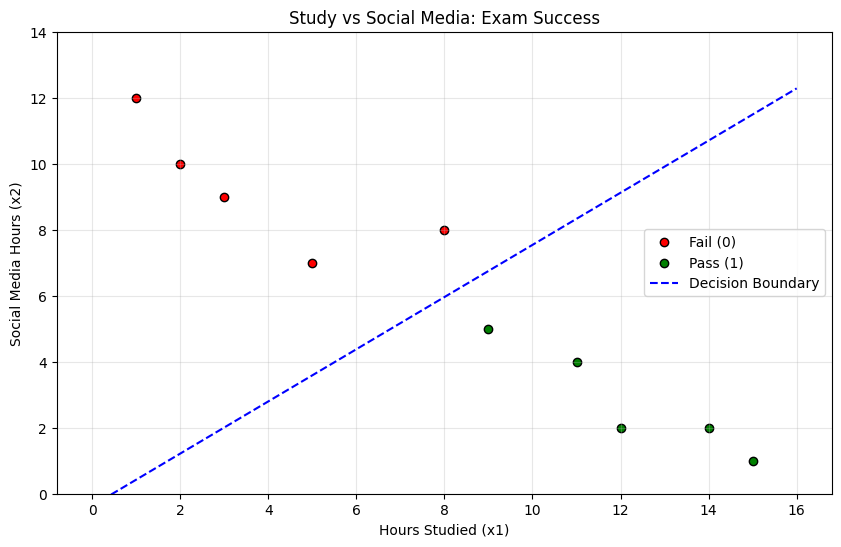

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot the student data points
plt.scatter(X[y==0, 0], X[y==0, 1], color='red', label='Fail (0)', edgecolors='k')
plt.scatter(X[y==1, 0], X[y==1, 1], color='green', label='Pass (1)', edgecolors='k')

# Create the Decision Boundary line (where w1*x1 + w2*x2 + b = 0)
x1_values = np.linspace(0, 16, 100)
# Rearranging the formula: x2 = -(w1*x1 + b) / w2
w1, w2 = model.coef_[0]
b = model.intercept_[0]
x2_values = -(w1 * x1_values + b) / w2

plt.plot(x1_values, x2_values, color='blue', linestyle='--', label='Decision Boundary')

plt.title("Study vs Social Media: Exam Success")
plt.xlabel("Hours Studied (x1)")
plt.ylabel("Social Media Hours (x2)")
plt.ylim(0, 14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()